# 09 — What explains the *extremes* (A7)
**Kernel: `Python (pf_ml)`.** Extremes two ways: **percentile** (per-surface p99 of the deep echo-top) and **absolute Zipser cuts** (40-dBZ ≥ 14 km; 37-GHz PCT ≤ 150 K). Non-deep features (no 40-dBZ echo) are non-extreme (ht40→0). Then composite environment of extremes vs typical, a class-weighted P(extreme) classifier explained with SHAP, and a quantile-GBM for the tail.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, warnings; warnings.filterwarnings('ignore')
from functools import reduce
from _shc import *
con = connect()
# Predictors: ambient CAPE + CIN + moisture + SKIN TEMP (skt; defined over land&ocean,
# unlike SST) + 3 shear layers + |lat|.  Treatment = 0-6 km shear.
PREDICTORS = [AMBIENT_CAPE, CIN, MOISTURE, 'mean_skt_2p50deg',
              'shear_1000m_centroid','shear_3000m_centroid','shear_6000m_centroid','abs_lat']
TREATMENT  = SHEAR
RESPONSES  = ['ht40_km','ht30_km','ht20_km','min_pct_85_89','min_pct_37']
# max_ht_40dbz is NULL when no 40-dBZ echo exists -> for echo-top HEIGHT models we sample the
# deep subset (finite ht40); CIN is occasionally NULL -> impute 0 (no inhibition).

# full convective population (don't require finite ht40 — absence = not extreme)
df = load_sample(con, ['ht40_km','min_pct_37','surf']+PREDICTORS, mission='TRMM', n=500_000)
df[CIN] = df[CIN].fillna(0.0); df['ht40_km'] = df['ht40_km'].fillna(0.0)
df = df.dropna(subset=PREDICTORS)
# absolute (Zipser) and percentile (per-surface) extreme labels
df['ext_abs'] = (df.ht40_km >= 14.0).astype(int)
thr = df[df.ht40_km>0].groupby('surf').ht40_km.quantile(0.99).to_dict()
df['ext_pct'] = df.apply(lambda r: int(r.ht40_km >= thr[r.surf]), axis=1)
print('prevalence  abs(>=14km)=%.4f  pct(per-surf p99)=%.4f  n=%d' % (df.ext_abs.mean(), df.ext_pct.mean(), len(df)))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

prevalence  abs(>=14km)=0.0000  pct(per-surf p99)=0.0010  n=500000


### Composite environment: extreme vs typical (what environment do the deep extremes inhabit?)

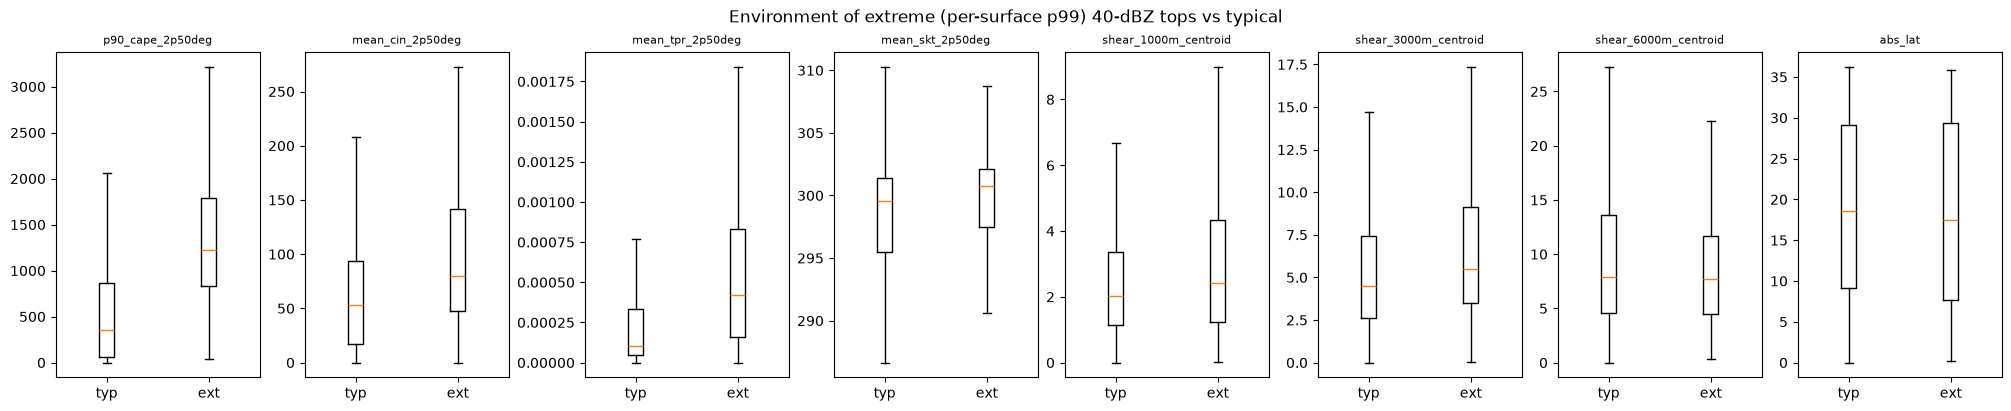

In [2]:
fig, axes = plt.subplots(1, len(PREDICTORS), figsize=(20,4), constrained_layout=True)
for ax,p in zip(axes, PREDICTORS):
    a = df.loc[df.ext_pct==1, p]; b = df.loc[df.ext_pct==0, p]
    ax.boxplot([b, a], tick_labels=['typ','ext'], showfliers=False); ax.set_title(p, fontsize=8)
fig.suptitle('Environment of extreme (per-surface p99) 40-dBZ tops vs typical'); plt.show()

### P(extreme) classifier + SHAP — ranked drivers of the deep-convection tail

test PR-AUC = 0.006 (baseline prevalence 0.001 )


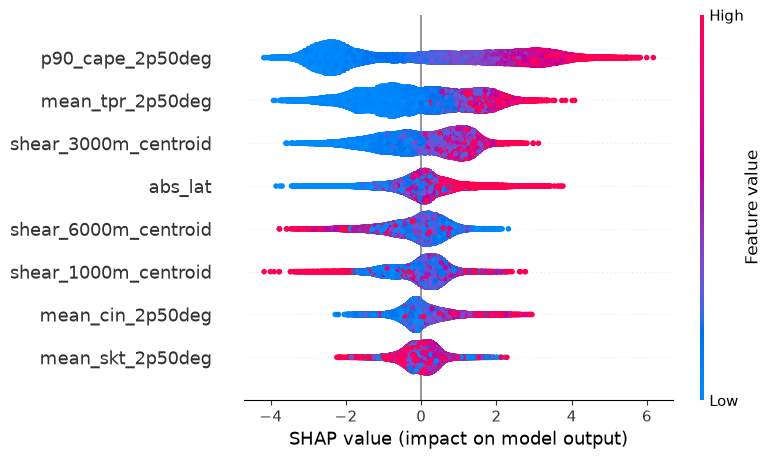

In [3]:
import lightgbm as lgb, shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
X, y = df[PREDICTORS], df['ext_pct']
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=.25, stratify=y, random_state=0)
clf = lgb.LGBMClassifier(n_estimators=600, learning_rate=.05, class_weight='balanced', verbose=-1).fit(Xtr, ytr)
print('test PR-AUC =', round(average_precision_score(yte, clf.predict_proba(Xte)[:,1]), 3),
      '(baseline prevalence', round(yte.mean(),4), ')')
sv = shap.TreeExplainer(clf)(Xte); shap.summary_plot(sv, Xte, show=True)

### Quantile-GBM for the p99 of the 40-dBZ top (the tail directly), with SHAP

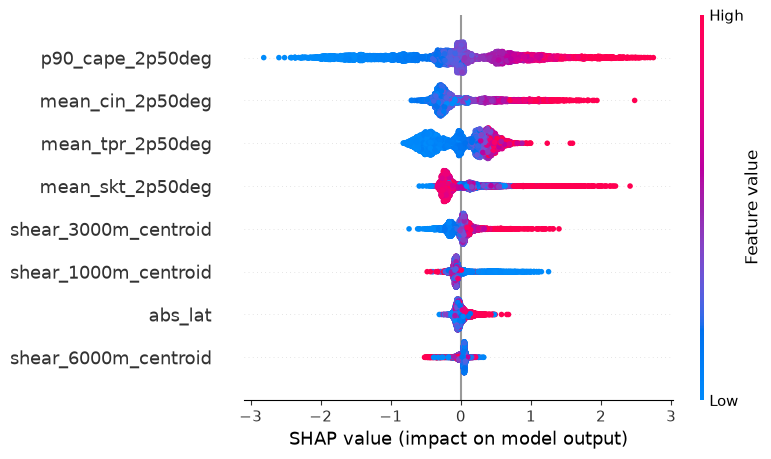

-> drivers of the 99th-percentile echo-top tail


In [4]:
import lightgbm as lgb, shap
from sklearn.model_selection import train_test_split
deep = df[df.ht40_km>0]
X, y = deep[PREDICTORS], deep['ht40_km']
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=.25, random_state=0)
qm = lgb.LGBMRegressor(objective='quantile', alpha=0.99, n_estimators=500, learning_rate=.05, verbose=-1).fit(Xtr, ytr)
samp = Xte.sample(min(5000,len(Xte)), random_state=0)
shap.summary_plot(shap.TreeExplainer(qm)(samp), samp, show=True)
print('-> drivers of the 99th-percentile echo-top tail')